# Build AnnData Object — GSE163834 PMN scRNA-seq

**Samples:**
| GSM ID | Description |
|---|---|
| GSM5211131 | PMN from blood of healthy donors, replicate 1 |
| GSM5211132 | PMN from blood of healthy donors, replicate 2 |
| GSM5211133 | PMN from blood of tumor burden patient, replicate 1 |
| GSM5211134 | PMN from blood of tumor burden patient, replicate 2 |


## 1. Import Required Libraries

In [2]:
import os
import gzip

import numpy as np
import pandas as pd
import scipy.io
import scipy.sparse

import anndata
import scanpy as sc

sc.settings.verbosity = 3
print(f"anndata version : {anndata.__version__}")
print(f"scanpy  version : {sc.__version__}")


anndata version : 0.11.4
scanpy  version : 1.11.5


/var/folders/g5/drz7gxc52xdftvrqcvh_9k5r0000gr/T/ipykernel_37822/520538411.py:14: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy  version : {sc.__version__}")


## 2. Define Sample Metadata

In [3]:
DATA_DIR = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "..", "data", "GSE163834_RAW"
)

SAMPLES = {
    "GSM5211131": {
        "prefix"    : "GSM5211131_BH.1",
        "condition" : "healthy",
        "replicate" : 1,
        "description": "PMN from blood of healthy donors, 1",
    },
    "GSM5211132": {
        "prefix"    : "GSM5211132_BH.2",
        "condition" : "healthy",
        "replicate" : 2,
        "description": "PMN from blood of healthy donors, 2",
    },
    "GSM5211133": {
        "prefix"    : "GSM5211133_BTB.1",
        "condition" : "tumor_burden",
        "replicate" : 1,
        "description": "PMN from blood of tumor burden patient, 1",
    },
    "GSM5211134": {
        "prefix"    : "GSM5211134_BTB.2",
        "condition" : "tumor_burden",
        "replicate" : 2,
        "description": "PMN from blood of tumor burden patient, 2",
    },
}

# Attach file paths
for gsm, meta in SAMPLES.items():
    pfx = meta["prefix"]
    meta["barcodes"] = os.path.join(DATA_DIR, f"{pfx}_barcodes.tsv.gz")
    meta["features"] = os.path.join(DATA_DIR, f"{pfx}_features.tsv.gz")
    meta["matrix"]   = os.path.join(DATA_DIR, f"{pfx}_matrix.mtx.gz")

# Quick sanity check
for gsm, meta in SAMPLES.items():
    for key in ("barcodes", "features", "matrix"):
        assert os.path.exists(meta[key]), f"Missing: {meta[key]}"
    print(f"{gsm}: all three files found ✓")


GSM5211131: all three files found ✓
GSM5211132: all three files found ✓
GSM5211133: all three files found ✓
GSM5211134: all three files found ✓


## 3. Load Barcodes

In [4]:
def load_barcodes(path: str) -> pd.Index:
    """Read a barcodes.tsv.gz file and return a pandas Index."""
    barcodes = pd.read_csv(path, header=None, sep="\t")[0]
    return pd.Index(barcodes, name="barcode")


# Load barcodes for every sample and store them back in SAMPLES
for gsm, meta in SAMPLES.items():
    meta["bc_index"] = load_barcodes(meta["barcodes"])
    print(f"{gsm}: {len(meta['bc_index']):,} barcodes")


GSM5211131: 2,740 barcodes
GSM5211132: 1,309 barcodes
GSM5211133: 3,192 barcodes
GSM5211134: 3,949 barcodes


## 4. Load Features (Genes)

In [5]:
def load_features(path: str) -> pd.DataFrame:
    """
    Read a features.tsv.gz file.
    Columns: gene_id | gene_name | feature_type  (10x v3 format).
    Returns a DataFrame indexed by gene_id with a gene_name column.
    """
    df = pd.read_csv(path, header=None, sep="\t")
    df.columns = ["gene_id", "gene_name"] + [f"col{i}" for i in range(2, len(df.columns))]
    df = df.set_index("gene_id")
    return df


# We only need to load features once (they are identical across samples),
# but we verify they are consistent across all four.
feature_dfs = {}
for gsm, meta in SAMPLES.items():
    feature_dfs[gsm] = load_features(meta["features"])
    print(f"{gsm}: {len(feature_dfs[gsm]):,} features")

# Use the first sample's feature table as the reference
var_df = feature_dfs["GSM5211131"][["gene_name"]].copy()

# Confirm all feature tables are identical
ref_index = var_df.index
for gsm, fdf in feature_dfs.items():
    assert ref_index.equals(fdf.index), f"Feature mismatch in {gsm}!"
print("\nAll feature tables are consistent ✓")
print(var_df.head())


GSM5211131: 60,234 features
GSM5211132: 60,234 features
GSM5211133: 60,234 features
GSM5211134: 60,234 features

All feature tables are consistent ✓
                       gene_name
gene_id                         
ENSG00000118473  ENSG00000118473
ENSG00000162426  ENSG00000162426
ENSG00000157191  ENSG00000157191
ENSG00000169504  ENSG00000169504
ENSG00000142920  ENSG00000142920


## 5. Load Count Matrix

In [6]:
def load_matrix(path: str) -> scipy.sparse.csr_matrix:
    """
    Read a matrix.mtx.gz file.
    The 10x MEX format stores genes × cells; we transpose to cells × genes (AnnData convention).
    """
    with gzip.open(path, "rb") as fh:
        mat = scipy.io.mmread(fh)          # returns COO matrix (genes × cells)
    return mat.T.tocsr()                   # → cells × genes, CSR format


for gsm, meta in SAMPLES.items():
    meta["matrix_csr"] = load_matrix(meta["matrix"])
    n_cells, n_genes = meta["matrix_csr"].shape
    print(f"{gsm}: matrix shape = {n_cells:,} cells × {n_genes:,} genes")


GSM5211131: matrix shape = 2,740 cells × 60,234 genes
GSM5211132: matrix shape = 1,309 cells × 60,234 genes
GSM5211133: matrix shape = 3,192 cells × 60,234 genes
GSM5211134: matrix shape = 3,949 cells × 60,234 genes


## 6. Build Individual AnnData Objects

In [7]:
adatas = {}

for gsm, meta in SAMPLES.items():
    # Prefix each barcode with the GSM ID to guarantee global uniqueness
    obs_names = pd.Index(
        [f"{gsm}_{bc}" for bc in meta["bc_index"]],
        name="cell_id"
    )

    adata = anndata.AnnData(
        X   = meta["matrix_csr"],        # cells × genes
        obs = pd.DataFrame(index=obs_names),
        var = var_df.copy(),
    )

    # Attach per-cell metadata from the sample dictionary
    adata.obs["sample_id"]   = gsm
    adata.obs["condition"]   = meta["condition"]
    adata.obs["replicate"]   = meta["replicate"]
    adata.obs["description"] = meta["description"]

    adatas[gsm] = adata
    print(f"{gsm}: AnnData{adata.shape}")


GSM5211131: AnnData(2740, 60234)
GSM5211132: AnnData(1309, 60234)
GSM5211133: AnnData(3192, 60234)
GSM5211134: AnnData(3949, 60234)


## 7. Concatenate AnnData Objects

In [14]:
adata = anndata.concat(
    adatas,                    # dict → keys are taken from dict automatically
    label  = "sample_id",     # adds/confirms sample_id column in obs
    join   = "outer",         # keep all genes (identical here, so effectively 'inner')
    merge  = "same",
)

# Ensure obs_names are unique (already prefixed, but just in case)
adata.obs_names_make_unique()

print(adata)
print("\nobs columns:", adata.obs.columns.tolist())
print("var columns:", adata.var.columns.tolist())


AnnData object with n_obs × n_vars = 11190 × 60234
    obs: 'sample_id', 'condition', 'replicate', 'description'
    var: 'gene_name'

obs columns: ['sample_id', 'condition', 'replicate', 'description']
var columns: ['gene_name']


## 8. Annotate Observations with Sample Metadata

In [10]:
# Build a lookup table from the SAMPLES dict
meta_df = pd.DataFrame(
    {gsm: {
        "condition"  : m["condition"],
        "replicate"  : m["replicate"],
        "description": m["description"],
    } for gsm, m in SAMPLES.items()}
).T

# Map metadata through the sample_id column already present in obs
for col in ["condition", "replicate", "description"]:
    adata.obs[col] = adata.obs["sample_id"].map(meta_df[col])

# Cast to appropriate dtypes
adata.obs["condition"]  = adata.obs["condition"].astype("category")
adata.obs["replicate"]  = adata.obs["replicate"].astype(int)
adata.obs["sample_id"]  = adata.obs["sample_id"].astype("category")

print(adata.obs.head(10))
print("\ncondition value counts:")
print(adata.obs["condition"].value_counts())


                                sample_id condition  replicate  \
cell_id                                                          
GSM5211131_AAACCTGAGACCACGA-1  GSM5211131   healthy          1   
GSM5211131_AAACCTGCACTATCTT-1  GSM5211131   healthy          1   
GSM5211131_AAACCTGCAGATGAGC-1  GSM5211131   healthy          1   
GSM5211131_AAACCTGCATGTCTCC-1  GSM5211131   healthy          1   
GSM5211131_AAACCTGTCCCAAGTA-1  GSM5211131   healthy          1   
GSM5211131_AAACGGGGTACGCTGC-1  GSM5211131   healthy          1   
GSM5211131_AAACGGGTCCCATTAT-1  GSM5211131   healthy          1   
GSM5211131_AAACGGGTCCGTCAAA-1  GSM5211131   healthy          1   
GSM5211131_AAAGATGAGTGGGCTA-1  GSM5211131   healthy          1   
GSM5211131_AAAGATGGTACGCTGC-1  GSM5211131   healthy          1   

                                                       description  
cell_id                                                             
GSM5211131_AAACCTGAGACCACGA-1  PMN from blood of healthy donors, 1  


## 9. Quality Control Metrics

In [11]:
# Flag mitochondrial genes (human: prefix "MT-")
adata.var["mt"] = adata.var["gene_name"].str.startswith("MT-")

# Calculate QC metrics with scanpy
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars     = ["mt"],   # will compute pct_counts_mt
    percent_top = None,
    log1p       = False,
    inplace     = True,
)

# Summary statistics
print("=== QC metric summary ===")
qc_cols = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
print(adata.obs[qc_cols].describe().round(2))


=== QC metric summary ===
       n_genes_by_counts  total_counts  pct_counts_mt
count           11190.00      11190.00        11190.0
mean              898.06       2317.50            0.0
std               564.72       2108.17            0.0
min                84.00        360.00            0.0
25%               428.00        721.00            0.0
50%               796.00       1673.50            0.0
75%              1256.00       3379.75            0.0
max              4769.00      30601.00            0.0


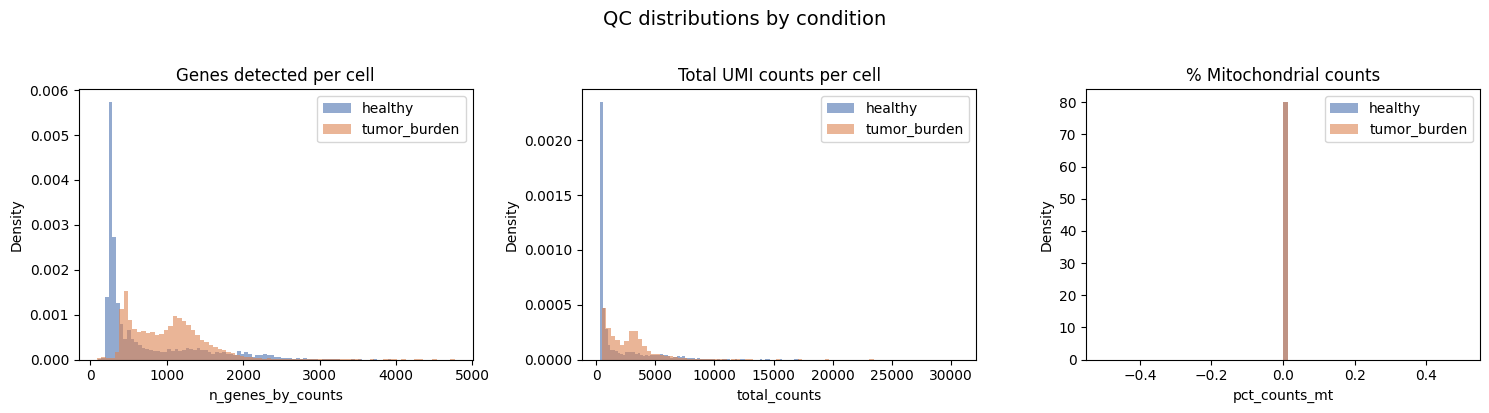

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

metrics = [
    ("n_genes_by_counts", "Genes detected per cell"),
    ("total_counts",      "Total UMI counts per cell"),
    ("pct_counts_mt",     "% Mitochondrial counts"),
]

colors = {"healthy": "#4C72B0", "tumor_burden": "#DD8452"}

for ax, (metric, title) in zip(axes, metrics):
    for cond, grp in adata.obs.groupby("condition", observed=True):
        ax.hist(grp[metric], bins=80, alpha=0.6,
                label=cond, color=colors[cond], density=True)
    ax.set_title(title)
    ax.set_xlabel(metric)
    ax.set_ylabel("Density")
    ax.legend()

fig.suptitle("QC distributions by condition", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 10. Save AnnData Object

In [13]:
OUTPUT_DIR = os.path.join(
    os.path.dirname(os.path.abspath("__file__")),
    "..", "results"
)
os.makedirs(OUTPUT_DIR, exist_ok=True)

out_path = os.path.join(OUTPUT_DIR, "GSE163834_PMN_adata.h5ad")
adata.write_h5ad(out_path, compression="gzip")

print(f"Saved → {out_path}")
print(f"\nFinal AnnData object summary:")
print(f"  Cells (obs) : {adata.n_obs:,}")
print(f"  Genes (var) : {adata.n_vars:,}")
print(f"\nobs metadata columns : {adata.obs.columns.tolist()}")
print(f"var metadata columns : {adata.var.columns.tolist()}")
print(f"\nSample breakdown:")
print(adata.obs.groupby(["sample_id", "condition", "replicate"], observed=True).size().reset_index(name="n_cells").to_string(index=False))


Saved → /Users/dgomez/workspace/Projects/R/DEEP-GOMS/Python/../results/GSE163834_PMN_adata.h5ad

Final AnnData object summary:
  Cells (obs) : 11,190
  Genes (var) : 60,234

obs metadata columns : ['sample_id', 'condition', 'replicate', 'description', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt']
var metadata columns : ['gene_name', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts']

Sample breakdown:
 sample_id    condition  replicate  n_cells
GSM5211131      healthy          1     2740
GSM5211132      healthy          2     1309
GSM5211133 tumor_burden          1     3192
GSM5211134 tumor_burden          2     3949
